<a href="https://colab.research.google.com/github/mariacastrom00/AI_exercises_MJCM/blob/main/assignment4_MJCM_AH2179.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises before assignment 4
By: Maria José Castro Moreno

Course: AH2179

You have learned and practiced the general process of building and training neural network models in TensorFlow-Keras in Python, and practical techniques of saving and loading the trained model, using the callback function to save the best model, best sizing of the neural networks, and dropout layer.

In this assignment, you will work on the neural network models in the practice session and tune the model parameters to achieve the best performance. You may consider tunning the sizing of the network and adding dropout layers.

Optional:

- Try adding interaction features (e.g., `hr * workingday`, `weathersit * hum`).
- Tune NN hyperparameters (layers, neurons, learning rate) via `GridSearchCV`.
- Consider more advanced architectures (e.g., gradient boosting, LSTMs for temporal structure).

## Data preparation


In [73]:
%pip install factor_analyzer

In [74]:
import pandas as pd
import numpy as np

# Import for task 1
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Import for task 2
import matplotlib.pyplot as plt
from sklearn.decomposition import KernelPCA

# Import for task 3
from sklearn.datasets import make_classification
# pip install factor_analyzer
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

# Import for task 3.3
from sklearn.decomposition import PCA, KernelPCA
import matplotlib.pyplot as plt

# Assignment 4 - Neural network model for bike-sharing demand prediction

In [75]:
url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'

df = pd.read_csv(url)

df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [76]:
print(df.shape)
print(df.columns)

df.info()

(17379, 17)
Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casua

In [77]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [78]:
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [79]:
# Remove target and variables that would cause data leakage

columns_to_drop = ['cnt']

if 'casual' in df.columns:
    columns_to_drop.append('casual')

if 'registered' in df.columns:
    columns_to_drop.append('registered')

X = df.drop(columns=columns_to_drop)
y = df['cnt']

print("Input variables:")
print(X.columns)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Input variables:
Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')

X shape: (17379, 14)
y shape: (17379,)


In [80]:
print(X.dtypes)

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
dtype: object


In [81]:
# Remove columns that should not be used as predictors

# First try
X = df.drop(columns=[
    'dteday',   # date as text/object
    'instant',  # just an ID/index
    'casual',   # remove if present - causes data leakage
    'registered', # remove if present - causes data leakage
    'cnt'       # target variable
], errors='ignore')

y = df['cnt']


In [82]:
print(X.columns)
print(X.dtypes)

print("X shape:", X.shape)
print("y shape:", y.shape)

Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
dtype: object
X shape: (17379, 12)
y shape: (17379,)


In [83]:
# Train/test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (13903, 12)
Test set: (3476, 12)


In [84]:
# Scale predictors

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(13903, 12)
(3476, 12)


### Model 1 - Baseline model plot (1 hidden layer, 32 neurons)

In [85]:
%pip install tensorflow.keras

In [86]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [87]:
# Compiling
baseline_model = Sequential([
    Dense(32,
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)), Dense(1)])

baseline_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 449 (1.75 KB)

 Trainable params: 449 (1.75 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
# Training
baseline_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'])

In [89]:
history_baseline = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1)

Epoch 1/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 67212.6250 - mae: 186.2598 - val_loss: 63313.1094 - val_mae: 176.9101
Epoch 2/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 55812.3906 - mae: 165.6516 - val_loss: 46819.8789 - val_mae: 146.8199
Epoch 3/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 38340.0078 - mae: 131.6715 - val_loss: 30875.0352 - val_mae: 114.8617
Epoch 4/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 27113.3652 - mae: 109.4896 - val_loss: 24032.9746 - val_mae: 103.4039
Epoch 5/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 23049.5312 - mae: 103.1888 - val_loss: 21787.4727 - val_mae: 100.6022
Epoch 6/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 21555.0762 - mae: 101.6065 - val_loss: 20847.7285 - val_mae: 100.1099
Epoch 7/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 20816.4414 - mae: 101.4719 - val_loss: 20397.5469 - val_mae: 100.4380
Epoch 8/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 20410.6816 - mae: 101

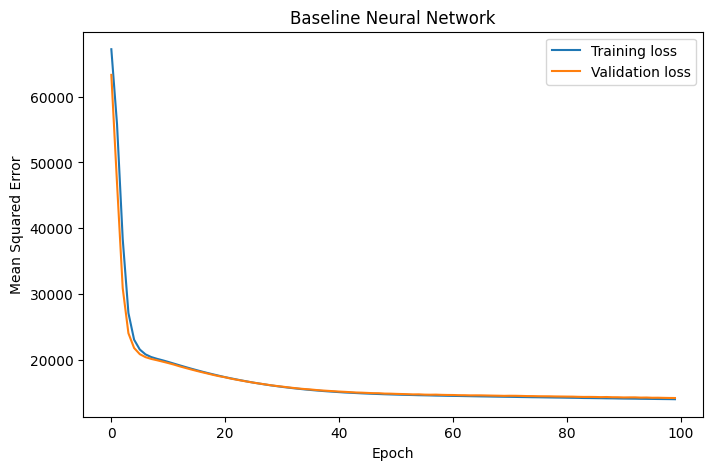

In [90]:
# MODEL 1
# Plot of learning curves
plt.figure(figsize=(8,5))

plt.plot(history_baseline.history['loss'], label='Training loss')

plt.plot(history_baseline.history['val_loss'], label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Baseline Neural Network')
plt.legend()

plt.show()

In [91]:
# Evaluation of model 1
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred_baseline = baseline_model.predict(X_test_scaled).flatten()

mse_baseline = mean_squared_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mse_baseline)
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print("MSE:", mse_baseline)
print("RMSE:", rmse_baseline)
print("MAE:", mae_baseline)
print("R²:", r2_baseline)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE: 13708.638671875
RMSE: 117.08389586905194
MAE: 87.54925537109375
R²: 0.5670784711837769


Comment: Both the training and the validation loss descrease rapidly for the first epochs (around 5). Both curves remain close to eachother during the training, indicating that overfitting cannot have a clear evidence.

Although, when evaluating the model (RMSE = 117.48, MAE = 88.00 and R² = 0.564) and with the final loss being realtively high the baseline netwrok is too simple to capture the whole relationship between input features and demand for bike sharing.

### Model 2 - Larger neural network (64-32 neurons)

In [92]:
# Model 2: Larger neural network

model_2 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)])

model_2.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'])

history_2 = model_2.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1)

Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


348/348 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 42411.8359 - mae: 140.0048 - val_loss: 20469.8438 - val_mae: 102.8951
Epoch 2/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 20346.3359 - mae: 104.2448 - val_loss: 20050.6172 - val_mae: 103.3034
Epoch 3/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 20059.3047 - mae: 103.9203 - val_loss: 19859.4062 - val_mae: 102.8991
Epoch 4/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 19909.2988 - mae: 103.5953 - val_loss: 19785.1113 - val_mae: 104.1828
Epoch 5/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 19799.9336 - mae: 103.5395 - val_loss: 19643.3613 - val_mae: 102.2811
Epoch 6/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 19721.1875 - mae: 103.0290 - val_loss: 19619.9980 - val_mae: 102.2655
Epoch 7/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 19637.2754 - mae: 102.9154 - val_loss: 19544.4961 - val_mae: 102.0583
Epoch 8/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 19540.5254 - mae: 102.7621 - val_

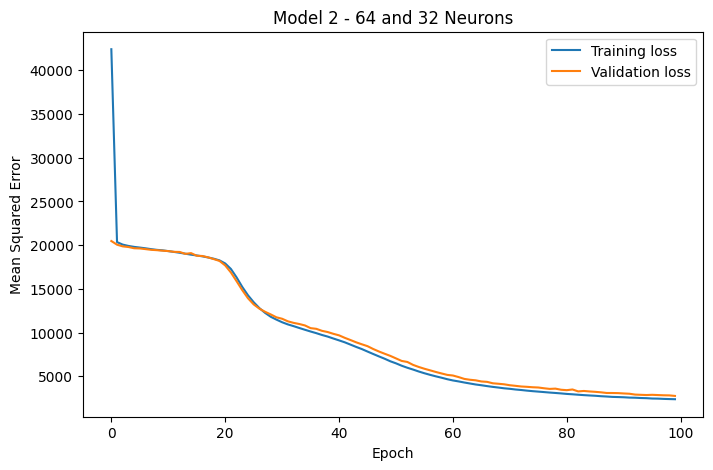

In [93]:
# MODEL 2
plt.figure(figsize=(8,5))

plt.plot(history_2.history['loss'], label='Training loss')
plt.plot(history_2.history['val_loss'], label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Model 2 - 64 and 32 Neurons')
plt.legend()

plt.show()

In [94]:
# Evaluation of model 2
y_pred_2 = model_2.predict(X_test_scaled).flatten()

mse_2 = mean_squared_error(y_test, y_pred_2)
rmse_2 = np.sqrt(mse_2)
mae_2 = mean_absolute_error(y_test, y_pred_2)
r2_2 = r2_score(y_test, y_pred_2)

print("Model 2 MSE:", mse_2)
print("Model 2 RMSE:", rmse_2)
print("Model 2 MAE:", mae_2)
print("Model 2 R²:", r2_2)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model 2 MSE: 2551.432861328125
Model 2 RMSE: 50.51171014060131
Model 2 MAE: 33.10062789916992
Model 2 R²: 0.9194252490997314


Comment: The training and validation losses decrease to much lower values than with the baseline model (lowest on y-axis is 20000).The larget network imrpoces the model capacity without introducing overfitting (Curves remain close throught the training).

Test performance show improvement, RMSE decreases to 64.57 and R² increases to 0.868. Indicating that an additional hidden layer (neural-network layer between the input and the final output) and increasing number of neurons allows the network to capture more complex relationships in the data.


### Model 3 - Larger architecture

In [95]:
# Model 3: Larger neural network
model_3 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model_3.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history_3 = model_3.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 30047.5508 - mae: 122.5873 - val_loss: 20242.1875 - val_mae: 105.8296
Epoch 2/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 20114.2949 - mae: 104.2454 - val_loss: 19793.7949 - val_mae: 102.1270
Epoch 3/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 19747.8555 - mae: 102.7924 - val_loss: 19332.3633 - val_mae: 101.9399
Epoch 4/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 18844.0117 - mae: 99.7718 - val_loss: 17844.9355 - val_mae: 95.1481
Epoch 5/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 16369.0068 - mae: 91.8305 - val_loss: 15084.6572 - val_mae: 87.2804
Epoch 6/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 14113.0762 - mae: 85.6483 - val_loss: 13562.1113 - val_mae: 81.6797
Epoch 7/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 12593.7725 - mae: 79.9366 - val_loss: 12166.9717 - val_mae: 75.9321
Epoch 8/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11320.8145 - mae: 75.1004 - val_loss: 1133

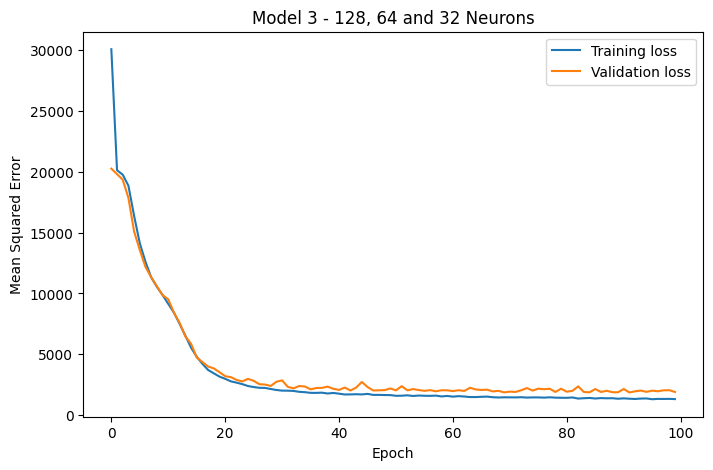

In [96]:
plt.figure(figsize=(8,5))

plt.plot(history_3.history['loss'], label='Training loss')
plt.plot(history_3.history['val_loss'], label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Model 3 - 128, 64 and 32 Neurons')
plt.legend()

plt.show()

In [97]:
y_pred_3 = model_3.predict(X_test_scaled).flatten()

mse_3 = mean_squared_error(y_test, y_pred_3)
rmse_3 = np.sqrt(mse_3)
mae_3 = mean_absolute_error(y_test, y_pred_3)
r2_3 = r2_score(y_test, y_pred_3)

print("Model 3 MSE:", mse_3)
print("Model 3 RMSE:", rmse_3)
print("Model 3 MAE:", mae_3)
print("Model 3 R²:", r2_3)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model 3 MSE: 1755.55517578125
Model 3 RMSE: 41.89934576793831
Model 3 MAE: 26.515968322753906
Model 3 R²: 0.9445592164993286


Comment: The model has a higher reduction in trianing and validation loss, mostly in the first part of training and stabilizing after aroung 30-40 epochs.

The training loss decreased slightly but validation loss was relatively stable. Some overfitting can be seen and a additional training is mainly improved on the training data.

Model 3, despite the slighty overfitting, has the best test performance, RMSE = 41.99, MAE = 26.10 and R² = 0.944. Showing that increasing the network size improved the predition for bike demand models.

### Model 4 - Model 3 + Dropouts

In [98]:
from tensorflow.keras.layers import Dropout

# Model 4: Model 3 with dropout

model_4 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)])

model_4.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'])

history_4 = model_4.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1)

Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 31275.3535 - mae: 124.1796 - val_loss: 20155.3926 - val_mae: 103.5827
Epoch 2/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 20625.8984 - mae: 104.9321 - val_loss: 19775.9375 - val_mae: 105.0780
Epoch 3/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 20249.4688 - mae: 103.8197 - val_loss: 19590.8086 - val_mae: 100.9003
Epoch 4/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 20054.5781 - mae: 103.2618 - val_loss: 19274.4551 - val_mae: 101.5535
Epoch 5/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 19810.6836 - mae: 102.7258 - val_loss: 19318.1758 - val_mae: 104.1279
Epoch 6/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 19857.1211 - mae: 103.1538 - val_loss: 19232.4883 - val_mae: 103.0816
Epoch 7/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 19678.7617 - mae: 102.3410 - val_loss: 19047.2656 - val_mae: 102.2040
Epoch 8/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 19713.1270 - mae: 102.7218 - val_l

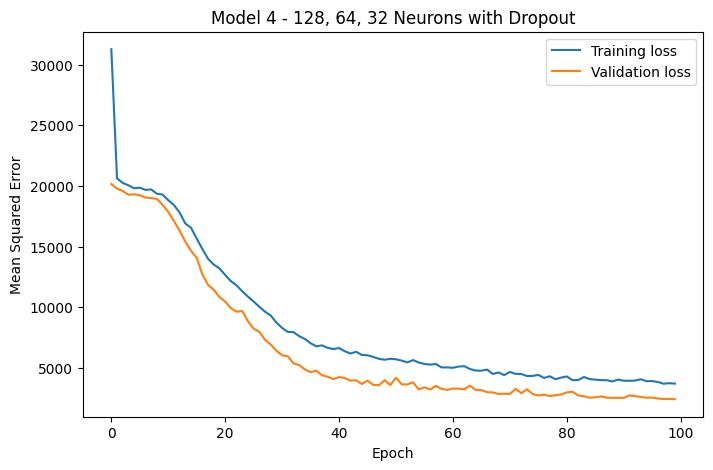

In [99]:
plt.figure(figsize=(8,5))

plt.plot(history_4.history['loss'], label='Training loss')
plt.plot(history_4.history['val_loss'], label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Model 4 - 128, 64, 32 Neurons with Dropout')
plt.legend()

plt.show()

In [100]:
y_pred_4 = model_4.predict(X_test_scaled).flatten()

mse_4 = mean_squared_error(y_test, y_pred_4)
rmse_4 = np.sqrt(mse_4)
mae_4 = mean_absolute_error(y_test, y_pred_4)
r2_4 = r2_score(y_test, y_pred_4)

print("Model 4 MSE:", mse_4)
print("Model 4 RMSE:", rmse_4)
print("Model 4 MAE:", mae_4)
print("Model 4 R²:", r2_4)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model 4 MSE: 2236.01416015625
Model 4 RMSE: 47.286511397609466
Model 4 MAE: 31.97135353088379
Model 4 R²: 0.9293862581253052


Comment: Dropout was added in this model, training loss is higher thn validation loss for the majority of the training process. The random dropout can be an explanation for this since it disables neurons during trianing, making the training task more difficult and dropout is disabled during the validation.

The test performance is slightly lower than model 3. RMSE increases from 41.99 to 47.59 and R² decreases from 0.944 to 0.928.

The dropout introduces more regularization than necessary for just this dataset and the model 4 is therefore not better than model 3 + dropout.

## Model 5 - Model 3 training with ModelCheckpoint and EarlyStopping

In [101]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Model 5: Model 3 architecture with callbacks

model_5 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model_5.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

checkpoint = ModelCheckpoint(
    'best_bike_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_5 = model_5.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

Epoch 1/200


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


337/348 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 46453.8548 - mae: 150.9899
Epoch 1: val_loss improved from None to 20199.11523, saving model to best_bike_model.keras

Epoch 1: finished saving model to best_bike_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 31044.5859 - mae: 124.2974 - val_loss: 20199.1152 - val_mae: 104.2992
Epoch 2/200
328/348 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20148.3452 - mae: 104.0145
Epoch 2: val_loss improved from 20199.11523 to 19973.12305, saving model to best_bike_model.keras

Epoch 2: finished saving model to best_bike_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 20092.9922 - mae: 103.9374 - val_loss: 19973.1230 - val_mae: 106.8601
Epoch 3/200
332/348 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19677.8316 - mae: 102.8915
Epoch 3: val_loss improved from 19973.12305 to 19231.14453, saving model to best_bike_model.keras

Epoch 3: finished saving model to best_bike_model.keras
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 196

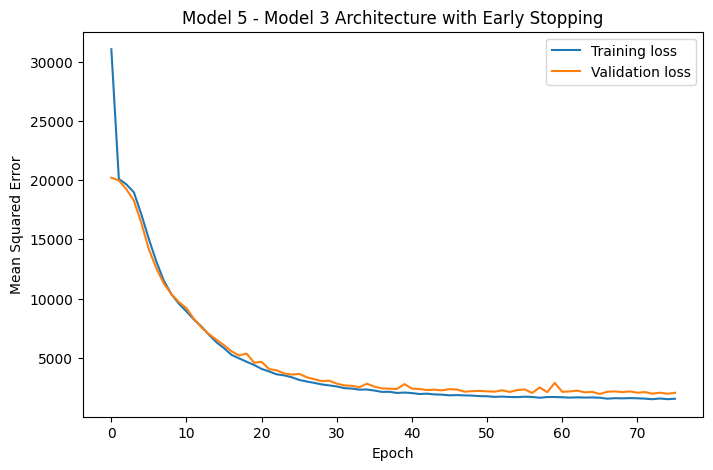

In [102]:
plt.figure(figsize=(8,5))

plt.plot(history_5.history['loss'], label='Training loss')
plt.plot(history_5.history['val_loss'], label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Model 5 - Model 3 Architecture with Early Stopping')
plt.legend()

plt.show()

In [103]:
from tensorflow.keras.models import load_model

best_model = load_model('best_bike_model.keras')

In [104]:
y_pred_best = best_model.predict(X_test_scaled).flatten()

mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("Best Model MSE:", mse_best)
print("Best Model RMSE:", rmse_best)
print("Best Model MAE:", mae_best)
print("Best Model R²:", r2_best)

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Best Model MSE: 1900.1712646484375
Best Model RMSE: 43.59095393138853
Best Model MAE: 27.58180046081543
Best Model R²: 0.9399921894073486


Comment: This model uses the same architecture as model 3 (128–64–32), and introduces EarlyStopping and ModelCheckpoint.

The callbacks monitor validation lsos and preserve the model corresponding to the best validation performance.


EarlyStopping --> Prevents unnecessary training once validation performance stops improving. ModelCheckpoint--> Ensures that the best performing version of the model is saved.

Values: RMSE = 44.48, MAE = 28.81 and R² = 0.938.  this Slightly worse than Model 3 on the test set, the callback approach provides a more robust training procedure and reduces the risk of training the network for unnecessarily many epochs.

In [105]:
results_final = pd.DataFrame({
    'Model': [
        'Baseline',
        'Model 2',
        'Model 3',
        'Model 4',
        'Best saved model'
    ],

    'Architecture': [
        '32',
        '64-32',
        '128-64-32',
        '128-64-32 + Dropout',
        '128-64-32 + EarlyStopping'
    ],

    'RMSE': [
        rmse_baseline,
        rmse_2,
        rmse_3,
        rmse_4,
        rmse_best
    ],

    'MAE': [
        mae_baseline,
        mae_2,
        mae_3,
        mae_4,
        mae_best
    ],

    'R2': [
        r2_baseline,
        r2_2,
        r2_3,
        r2_4,
        r2_best
    ]
})

results_final

,Model,Architecture,RMSE,MAE,R2
0,Baseline,32,117.083896,87.549255,0.567078
1,Model 2,64-32,50.511710,33.100628,0.919425
2,Model 3,128-64-32,41.899346,26.515968,0.944559
3,Model 4,128-64-32 + Dropout,47.286511,31.971354,0.929386
4,Best saved model,128-64-32 + EarlyStopping,43.590954,27.581800,0.939992



Increasing the size of the neural network consistently improved prediction performance from the baseline model to Model 3. The largest improvement occurred when moving from the single-layer baseline model to deeper architectures.

Model 3 (128–64–32) achieved the best overall test performance, with the lowest RMSE and MAE and the highest R². Adding dropout slightly reduced performance, suggesting that strong regularization was not necessary for this dataset.

The EarlyStopping model also performed well, but did not outperform Model 3 on the test set. Therefore, Model 3 is selected as the best-performing neural network configuration in this experiment.

## Actual VS Predicted plot - Model 3

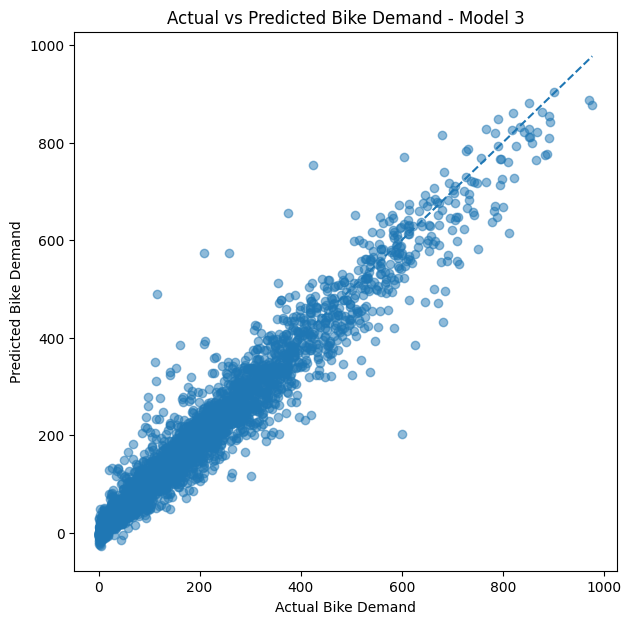

In [106]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred_3,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Bike Demand')
plt.ylabel('Predicted Bike Demand')
plt.title('Actual vs Predicted Bike Demand - Model 3')

plt.show()


The predicted values generally follow the observed bike-sharing demand, with many observations located close to the diagonal reference line. This is consistent with the high R² value obtained by Model 3.

The spread becomes larger for some high-demand observations, indicating that the model still has difficulty predicting certain extreme demand values. However, overall the plot shows a strong agreement between predicted and observed demand.

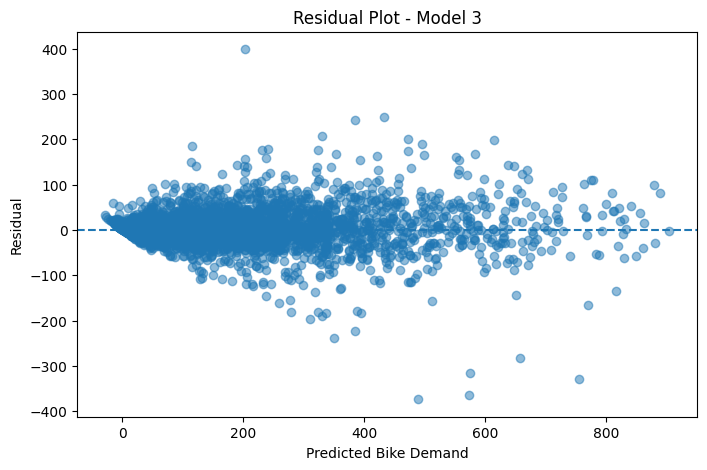

In [107]:
residuals_3 = y_test - y_pred_3

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_3,
    residuals_3,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Bike Demand')
plt.ylabel('Residual')
plt.title('Residual Plot - Model 3')

plt.show()